Dataset Shape: (569, 31)

First 5 rows:
    diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0   

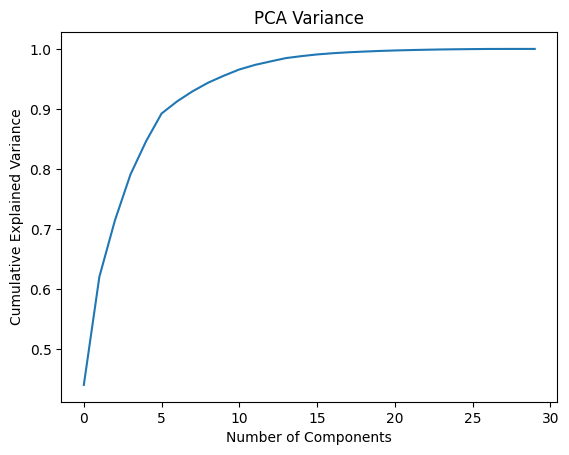


KNN (Original)
Accuracy:
0.9473684210526315
Precision:
0.9302325581395349
Recall:
0.9302325581395349
F1 Score:
0.9302325581395349
Confusion Matrix:
[[68  3]
 [ 3 40]]

SVM (Original)
Accuracy:
0.9736842105263158
Precision:
0.9761904761904762
Recall:
0.9534883720930233
F1 Score:
0.9647058823529412
Confusion Matrix:
[[70  1]
 [ 2 41]]

KNN (PCA)
Accuracy:
0.9649122807017544
Precision:
0.975609756097561
Recall:
0.9302325581395349
F1 Score:
0.9523809523809523
Confusion Matrix:
[[70  1]
 [ 3 40]]

SVM (PCA)
Accuracy:
0.9649122807017544
Precision:
0.975609756097561
Recall:
0.9302325581395349
F1 Score:
0.9523809523809523
Confusion Matrix:
[[70  1]
 [ 3 40]]

Final Comparison Table:

            Model  Accuracy  Precision    Recall        F1
0  KNN (Original)  0.947368   0.930233  0.930233  0.930233
1  SVM (Original)  0.973684   0.976190  0.953488  0.964706
2       KNN (PCA)  0.964912   0.975610  0.930233  0.952381
3       SVM (PCA)  0.964912   0.975610  0.930233  0.952381


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("data.csv")

df = df.drop(["id", "Unnamed: 32"], axis=1)

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nTarget Distribution:\n", df["diagnosis"].value_counts())

df = df.fillna(df.mean(numeric_only=True))

y = df["diagnosis"]
X = df.drop("diagnosis", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(X_train)

mask = y_pred_iso != -1
X_train_clean = X_train[mask]
y_train_clean = y_train.iloc[mask]

print("\nOriginal size:", X_train.shape)
print("After removing anomalies:", X_train_clean.shape)

anomaly_percent = np.mean(y_pred_iso == -1) * 100
print("Anomalies detected: {:.2f}%".format(anomaly_percent))

pca = PCA()
pca.fit(X_train_clean)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance")
plt.show()

pca_2 = PCA(n_components=2)
X_train_pca = pca_2.fit_transform(X_train_clean)
X_test_pca = pca_2.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_clean, y_train_clean)

svm = SVC()
svm.fit(X_train_clean, y_train_clean)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train_clean)

svm_pca = SVC()
svm_pca.fit(X_train_pca, y_train_clean)

def evaluate(model, X, y_true):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

results = {
    "KNN (Original)": evaluate(knn, X_test, y_test),
    "SVM (Original)": evaluate(svm, X_test, y_test),
    "KNN (PCA)": evaluate(knn_pca, X_test_pca, y_test),
    "SVM (PCA)": evaluate(svm_pca, X_test_pca, y_test)
}

for model, metrics in results.items():
    print("\n==============================")
    print(model)
    print("==============================")
    for k, v in metrics.items():
        print(f"{k}:\n{v}")

comparison = []

for model, metrics in results.items():
    comparison.append([
        model,
        metrics["Accuracy"],
        metrics["Precision"],
        metrics["Recall"],
        metrics["F1 Score"]
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

print("\nFinal Comparison Table:\n")
print(comparison_df)

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Dataset summary
print(X.shape)
print(y.value_counts())

# Check missing values
print(X.isnull().sum())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

(569, 30)
1    357
0    212
Name: count, dtype: int64
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [2]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
y_pred = iso.fit_predict(X_train)

# Convert (-1 = anomaly, 1 = normal)
mask = y_pred != -1

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print("Original size:", X_train.shape)
print("After cleaning:", X_train_clean.shape)

anomaly_percent = np.mean(y_pred == -1) * 100
print("Anomalies detected:", anomaly_percent, "%")

Original size: (455, 30)
After cleaning: (432, 30)
Anomalies detected: 5.054945054945055 %


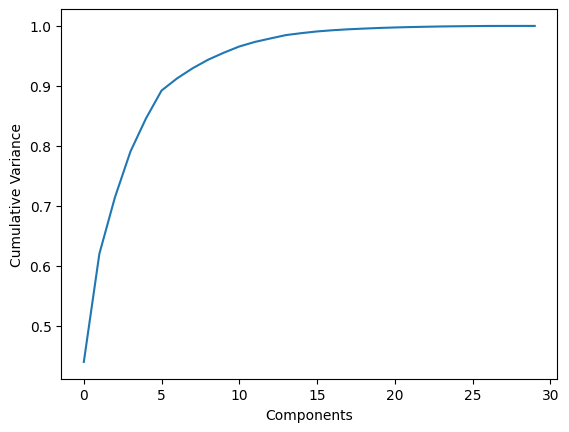

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA for variance
pca = PCA()
pca.fit(X_train_clean)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

# PCA (2D)
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train_clean)

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Models
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC()

# Train on original cleaned data
knn.fit(X_train_clean, y_train_clean)
svm.fit(X_train_clean, y_train_clean)

# Train on PCA data
X_test_pca2 = pca_2.transform(X_test)

knn_pca = KNeighborsClassifier(n_neighbors=5)
svm_pca = SVC()

knn_pca.fit(X_train_pca2, y_train_clean)
svm_pca.fit(X_train_pca2, y_train_clean)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(model, X, y_true):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

# Evaluate models
results = {
    "KNN Original": evaluate(knn, X_test, y_test),
    "SVM Original": evaluate(svm, X_test, y_test),
    "KNN PCA": evaluate(knn_pca, X_test_pca2, y_test),
    "SVM PCA": evaluate(svm_pca, X_test_pca2, y_test),
}

for k, v in results.items():
    print("\n", k)
    for metric, value in v.items():
        print(metric, ":\n", value)


 KNN Original
Accuracy :
 0.9473684210526315
Precision :
 0.9577464788732394
Recall :
 0.9577464788732394
F1 :
 0.9577464788732394
Confusion Matrix :
 [[40  3]
 [ 3 68]]

 SVM Original
Accuracy :
 0.9736842105263158
Precision :
 0.9722222222222222
Recall :
 0.9859154929577465
F1 :
 0.9790209790209791
Confusion Matrix :
 [[41  2]
 [ 1 70]]

 KNN PCA
Accuracy :
 0.9649122807017544
Precision :
 0.958904109589041
Recall :
 0.9859154929577465
F1 :
 0.9722222222222222
Confusion Matrix :
 [[40  3]
 [ 1 70]]

 SVM PCA
Accuracy :
 0.9649122807017544
Precision :
 0.958904109589041
Recall :
 0.9859154929577465
F1 :
 0.9722222222222222
Confusion Matrix :
 [[40  3]
 [ 1 70]]
